# Multiple Linear Regression Model

### House Price Prediction

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
# Load Dataset
df = pd.read_csv('house_price.csv')
df.head()


,Area,Bedrooms,price
0,800,2.0,40
1,1000,NaN,55
2,1200,3.0,60
3,1500,4.0,75
4,1800,4.0,85


In [3]:
# System Maximum rows
print(pd.options.display.max_rows)

60


In [4]:
df.shape

(8, 3)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Area      8 non-null      int64  
 1   Bedrooms  7 non-null      float64
 2    price    8 non-null      int64  
dtypes: float64(1), int64(2)
memory usage: 324.0 bytes


In [6]:
df.describe()

,Area,Bedrooms,price
count,8.000000,7.000000,8.000000
mean,1625.000000,4.142857,79.375000
std,601.783065,1.345185,27.049888
min,800.000000,2.000000,40.000000
25%,1150.000000,3.500000,58.750000
50%,1650.000000,4.000000,80.000000
75%,2050.000000,5.000000,97.500000
max,2500.000000,6.000000,120.000000


In [7]:
(df.isnull().sum()/df.shape[0])*100

Area         0.0
Bedrooms    12.5
 price       0.0
dtype: float64

<Axes: >

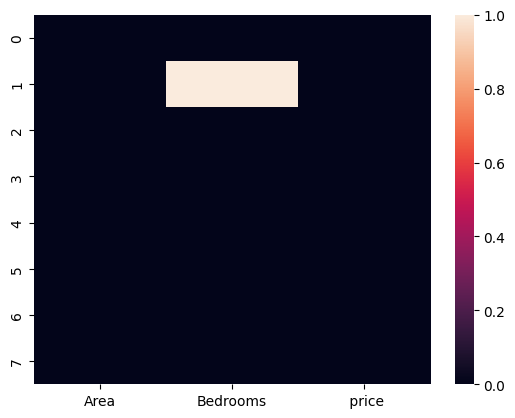

In [8]:
sns.heatmap(df.isnull())

In [9]:
df.corr()

,Area,Bedrooms,price
Area,1.000000,0.983996,0.997173
Bedrooms,0.983996,1.000000,0.988682
price,0.997173,0.988682,1.000000


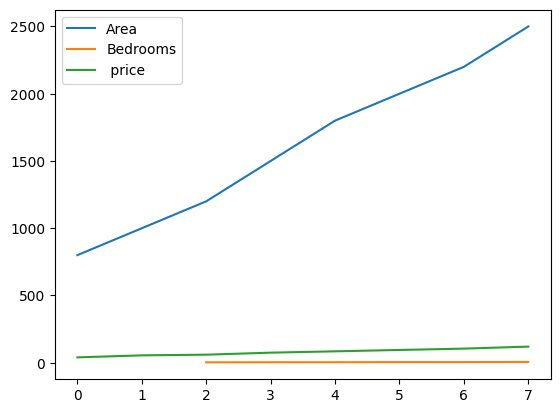

In [10]:
df.plot()
plt.show()

In [11]:
# fill missing values
df['Bedrooms'] = df['Bedrooms'].fillna(df['Bedrooms'].mean())



#### Linear Regression Model


In [12]:
print(df.columns)


Index(['Area', 'Bedrooms', ' price'], dtype='str')


In [13]:
X = df[['Area','Bedrooms']]
y = df[' price']

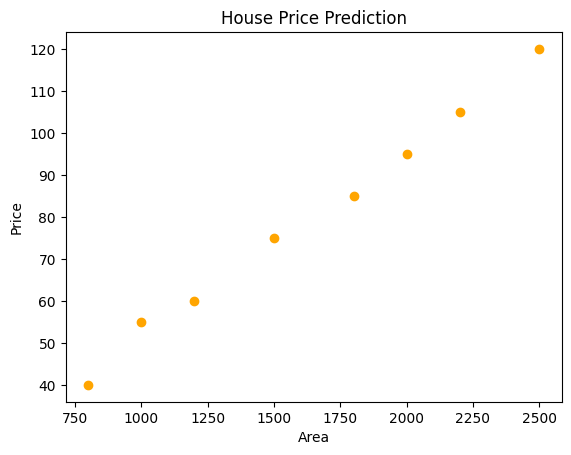

In [14]:
# Scatter plot
plt.scatter(df['Area'],y,color = 'orange')
plt.title('House Price Prediction')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

In [15]:
# split data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [16]:
lin = LinearRegression()
lin.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_predict = lin.predict(X_test)
print(y_predict)

[58.73754153 97.6744186 ]


In [18]:
print(f"MAE: {mean_absolute_error(y_test,y_predict)}")
print(f"MSE: {mean_squared_error(y_test,y_predict)}")
print(f"R2: {r2_score(y_test,y_predict)}")

MAE: 3.2059800664451856
MSE: 10.560865774108457
R2: 0.9735978355647289


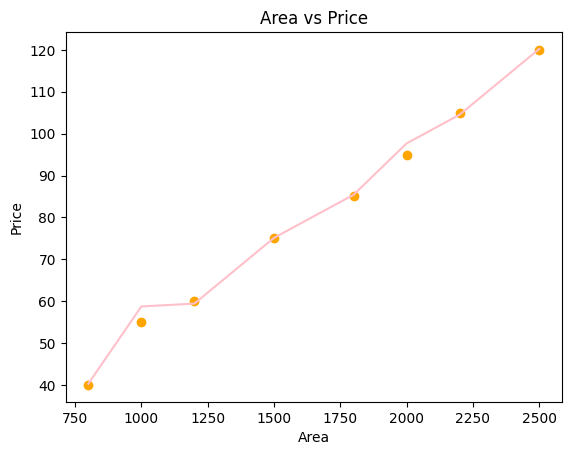

In [19]:
# Scatter plot of Linear Regression by red line
plt.scatter(df['Area'], df[' price'], color='orange')
plt.plot(df['Area'], lin.predict(X), color='pink')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

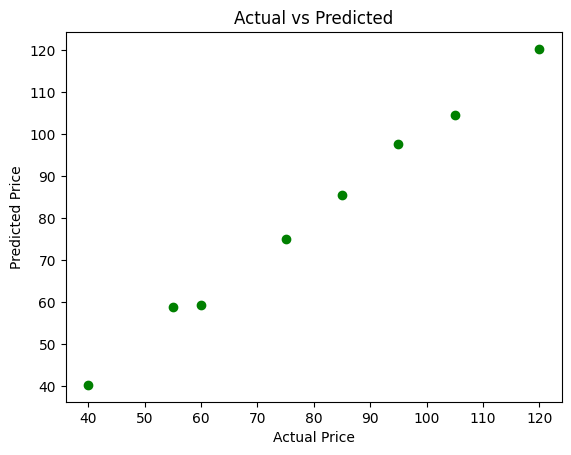

In [20]:
y_pred = lin.predict(X)

plt.scatter(y, y_pred, color='green')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

## Finally, I Learnt Multiple Linear Regression Model!!!!!!!!!!!!!!!!